# SemEval-2026 Task 13 — Task A: Binary Machine-Generated Code Detection
**Model:**   
**Platform:** Kaggle / Google Colab GPU (T4 or A100)

---
## Paper-Aligned Hyperparameters (CoDet-M4, arXiv:2503.13733)

| Setting | Value | Source |
|---|---|---|
| Learning rate |  | Paper §4.1 |
| Weight decay |  | Paper §4.1 |
| Epochs |  | Paper §4.1 |
| Effective batch |  (16×16 on T4, 32×8 on A100) | Paper §4.1 |
| Classifier | Linear(768→768) + Tanh + Linear(768→2) | BERT-style pooler |

## Required Outputs
| Category | Metrics / Files |
|---|---|
| **Primary** (→ ) | Macro F1 *(primary)*, Binary F1, Accuracy, Macro Precision, Macro Recall, ROC AUC |
| **Visualisations** (→ disk) | ,  (PR-curve),  |


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 — Install Dependencies

In [2]:
!pip install -q transformers datasets accelerate scikit-learn pandas pyarrow shap matplotlib seaborn
print("Dependencies installed")

Dependencies installed


## Cell 2 — Imports & Config

In [3]:
import os, sys, json, random, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from datasets import load_dataset
warnings.filterwarnings("ignore")


class CFG:
    model_name   = "microsoft/codebert-base"
    num_labels   = 2                      # 0=human, 1=machine
    hf_dataset_id = "DaniilOr/SemEval-2026-Task13"
    hf_subset    = "A"                    # correct config name
    train_samples = 100_000
    val_samples   = 20_000
    max_len      = 512
    # HALF = (512-2)//2 = 255  →  [CLS]+255+255+[SEP] = 512 exactly
    HALF         = (512 - 2) // 2        # 255
    epochs       = 3
    batch_size   = 16
    grad_accum   = 16
    lr           = 3e-4
    weight_decay = 1e-3
    warmup_ratio = 0.06
    fp16         = True
    seed         = 42
    # Auto-detect environment
    output_dir   = ("/content/codebert_taskA"
                    if os.path.exists("/content")
                    else "/kaggle/working/codebert_taskA")

# Derived paths (set after output_dir is defined)
CFG.best_model_path = CFG.output_dir + "/best_model.pt"
CFG.log_path        = CFG.output_dir + "/bert_train.out"
CFG.submission_path = CFG.output_dir + "/submission_codebert_taskA.csv"
CFG.device          = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)


set_seed(CFG.seed)
os.makedirs(CFG.output_dir, exist_ok=True)

# Logging — writes to bert_train.out AND stdout
import logging
logger = logging.getLogger("codebert")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh  = logging.FileHandler(CFG.log_path, mode="w")
sh  = logging.StreamHandler(sys.stdout)
fmt = logging.Formatter("%(asctime)s | %(message)s", datefmt="%H:%M:%S")
fh.setFormatter(fmt); sh.setFormatter(fmt)
logger.addHandler(fh); logger.addHandler(sh)

env = "Colab" if os.path.exists("/content") else "Kaggle"
logger.info(f"Environment : {env}")
logger.info(f"Output dir  : {CFG.output_dir}")
logger.info(f"Device      : {CFG.device}")

if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    logger.info(f"GPU: {torch.cuda.get_device_name(0)} ({vram_gb:.1f} GB)")
    if vram_gb > 35:
        CFG.batch_size = 32; CFG.grad_accum = 8
        logger.info("A100 detected -> batch=32, accum=8")
    else:
        logger.info("T4 detected -> batch=16, accum=16")

logger.info(f"Eff.batch={CFG.batch_size*CFG.grad_accum} | LR={CFG.lr} | "
            f"WD={CFG.weight_decay} | Epochs={CFG.epochs}")
logger.info(f"Truncation: [CLS]+{CFG.HALF}+{CFG.HALF}+[SEP] = {2+2*CFG.HALF} tokens")


04:07:27 | Environment : Colab


INFO:codebert:Environment : Colab


04:07:28 | Output dir  : /content/codebert_taskA


INFO:codebert:Output dir  : /content/codebert_taskA


04:07:28 | Device      : cuda


...

INFO:codebert:T4 detected -> batch=16, accum=16


04:07:28 | Eff.batch=256 | LR=0.0003 | WD=0.001 | Epochs=3


INFO:codebert:Eff.batch=256 | LR=0.0003 | WD=0.001 | Epochs=3


04:07:28 | Truncation: [CLS]+255+255+[SEP] = 512 tokens


INFO:codebert:Truncation: [CLS]+255+255+[SEP] = 512 tokens


## Cell 3 — Load & Stratify Data

> Stratified by  to preserve paper dataset proportions.
> Tries HuggingFace Hub first, falls back to local Kaggle parquet.

In [4]:
def load_and_sample(split, n_samples):
    """
    Load split from HF Hub (config="A") with Kaggle-local parquet fallback.
    split: "train" | "validation"
    """
    logger.info(f"Loading '{split}' (config='{CFG.hf_subset}')...")
    df = None

    # 1. HuggingFace Hub
    try:
        ds = load_dataset(
            CFG.hf_dataset_id, CFG.hf_subset,
            split=split, streaming=True, trust_remote_code=True,
        )
        records, target = [], (n_samples * 5 if n_samples else 999_999)
        for i, row in enumerate(ds):
            records.append(row)
            if i >= target: break
        df = pd.DataFrame(records)
        logger.info(f"  HF Hub OK — {len(df):,} rows")
    except Exception as e:
        logger.info(f"  HF Hub failed: {e}")

    # 2. Local parquet fallback (Kaggle)
    if df is None:
        candidates = [
            f"/kaggle/input/semeval-2026-task13/A/{split}.parquet",
            f"/kaggle/input/semeval-2026-task13/task_A/{split}.parquet",
            f"/kaggle/input/semeval-2026-task13/{split}.parquet",
        ]
        for path in candidates:
            if os.path.exists(path):
                logger.info(f"  Reading local parquet: {path}")
                df = pd.read_parquet(path)
                break
        if df is None:
            raise FileNotFoundError(
                f"Cannot load '{split}'. Tried HF Hub config='A' and:\n"
                + "\n".join(f"  {p}" for p in candidates)
            )

    # 3. Normalise column names
    df.columns = [c.strip().lower() for c in df.columns]
    for alt in ["source", "snippet", "text", "content"]:
        if alt in df.columns and "code" not in df.columns:
            df = df.rename(columns={alt: "code"})
    for alt in ["target", "is_ai", "generated", "class"]:
        if alt in df.columns and "label" not in df.columns:
            df = df.rename(columns={alt: "label"})
    for col in ["code", "label"]:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found. Available: {list(df.columns)}")
    df["label"] = df["label"].astype(int)

    # 4. Stratified sampling
    if n_samples and len(df) > n_samples:
        strat_cols = [c for c in ["label", "language"] if c in df.columns]
        if strat_cols:
            df = (df.groupby(strat_cols, group_keys=False)
                    .apply(lambda g: g.sample(
                        min(len(g), max(1, int(n_samples * len(g) / len(df)))),
                        random_state=CFG.seed)))
        df = df.sample(min(n_samples, len(df)), random_state=CFG.seed).reset_index(drop=True)

    label_dist = df["label"].value_counts().to_dict()
    lang_dist  = df["language"].value_counts().to_dict() if "language" in df.columns else "N/A"
    logger.info(f"  {split}: {len(df):,} rows | labels={label_dist} | langs={lang_dist}")
    return df


train_df = load_and_sample("train",      CFG.train_samples)
val_df   = load_and_sample("validation", CFG.val_samples)
logger.info("Data loading complete.")


04:07:28 | Loading 'train' (config='A')...


INFO:codebert:Loading 'train' (config='A')...
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'DaniilOr/SemEval-2026-Task13' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'DaniilOr/SemEval-2026-Task13' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/801 [00:00<?, ?B/s]

04:09:18 |   HF Hub OK — 500,000 rows


INFO:codebert:  HF Hub OK — 500,000 rows


...

INFO:codebert:  HF Hub OK — 100,000 rows


04:09:36 |   validation: 19,999 rows | labels={1: 10460, 0: 9539} | langs={'Python': 18292, 'C++': 935, 'Java': 772}


INFO:codebert:  validation: 19,999 rows | labels={1: 10460, 0: 9539} | langs={'Python': 18292, 'C++': 935, 'Java': 772}


04:09:36 | Data loading complete.


INFO:codebert:Data loading complete.


## Cell 4 — Tokenizer & First+Last-256 Truncation

| Region | Tokens | Key SHAP features (paper Appendix G) |
|---|---|---|
| First 256 | Imports, function signatures | ,  |
| Last 256 | Return logic, endings | , human idiosyncrasies |
| ≤512 total | Full sequence | No truncation loss for short snippets |

In [5]:
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)


def tokenize_first_last(code: str) -> dict:
    """
    Fixed-length tokenization: always returns exactly max_len=512 tokens.
    Strategy: [CLS] + first_255 + last_255 + [SEP] = 512
    Short sequences (<=510 tokens) are kept in full and padded normally.
    Hard clamp [:MAX] prevents any off-by-one edge case.
    """
    MAX   = CFG.max_len        # 512
    INNER = MAX - 2            # 510  (space between CLS and SEP)
    HALF  = CFG.HALF           # 255

    tokens = tokenizer(code, add_special_tokens=False, truncation=False)
    ids    = tokens["input_ids"]

    if len(ids) <= INNER:
        enc = tokenizer(
            code, max_length=MAX,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {k: v.squeeze(0) for k, v in enc.items()}

    # [CLS] + first_255 + last_255 + [SEP]  =>  512 tokens
    merged = ([tokenizer.cls_token_id]
              + ids[:HALF]
              + ids[-HALF:]
              + [tokenizer.sep_token_id])
    merged = merged[:MAX]                     # hard clamp
    pad    = MAX - len(merged)
    merged = merged + [tokenizer.pad_token_id] * pad
    attn   = [1] * (MAX - pad) + [0] * pad

    return {
        "input_ids":      torch.tensor(merged, dtype=torch.long),
        "attention_mask": torch.tensor(attn,   dtype=torch.long),
    }


# Sanity checks — both must print shape torch.Size([512])
enc_short = tokenize_first_last(train_df["code"].iloc[0])
enc_long  = tokenize_first_last("x = 1\n" * 3000)
assert enc_short["input_ids"].shape[0] == CFG.max_len
assert enc_long["input_ids"].shape[0]  == CFG.max_len
logger.info(f"Tokenizer OK | short={enc_short['input_ids'].shape} | "
            f"long={enc_long['input_ids'].shape} | "
            f"strategy=[CLS]+{CFG.HALF}+{CFG.HALF}+[SEP]={CFG.max_len}"
)


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (12000 > 512). Running this sequence through the model will result in indexing errors


04:09:37 | Tokenizer OK | short=torch.Size([512]) | long=torch.Size([512]) | strategy=[CLS]+255+255+[SEP]=512


INFO:codebert:Tokenizer OK | short=torch.Size([512]) | long=torch.Size([512]) | strategy=[CLS]+255+255+[SEP]=512


## Cell 5 — Dataset & DataLoaders

In [6]:
class CodeDataset(Dataset):
    def __init__(self, df, has_labels=True):
        self.codes      = df["code"].tolist()
        self.has_labels = has_labels
        self.labels     = df["label"].tolist() if has_labels else None
        self.ids        = df["id"].tolist() if "id" in df.columns else list(range(len(df)))
    def __len__(self): return len(self.codes)
    def __getitem__(self, idx):
        enc  = tokenize_first_last(self.codes[idx])
        item = {
            "input_ids":      enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "sample_id":      self.ids[idx],
        }
        if self.has_labels:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# num_workers=2 on Colab/Kaggle; set to 0 if you see worker errors
NW = 2
train_ds = CodeDataset(train_df)
val_ds   = CodeDataset(val_df)
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size,
                          shuffle=True,  num_workers=NW, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size * 2,
                          shuffle=False, num_workers=NW, pin_memory=True)
logger.info(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches "
            f"| Eff.batch={CFG.batch_size*CFG.grad_accum}")


04:09:37 | Train: 6250 batches | Val: 625 batches | Eff.batch=256


INFO:codebert:Train: 6250 batches | Val: 625 batches | Eff.batch=256


## Cell 6 — CodeBERT Classifier



In [7]:
class CodeBERTClassifier(nn.Module):
    def __init__(self, model_name, num_labels=2, dropout=0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size  # 768
        self.dropout    = nn.Dropout(dropout)
        # BERT-style pooler head — consistent with CodeBERT pre-training
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Dropout(dropout), nn.Linear(hidden, num_labels),
        )
    def forward(self, input_ids, attention_mask, labels=None):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls    = self.dropout(out.last_hidden_state[:, 0, :])
        logits = self.classifier(cls)
        loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return loss, logits

model = CodeBERTClassifier(CFG.model_name, CFG.num_labels).to(CFG.device)
n_params = sum(p.numel() for p in model.parameters())
logger.info(f"CodeBERT params: {n_params:,} | device: {CFG.device}")
logger.info("Paper target — Binary F1: 95.70 (Table 2, seen lang/domain, full 500K)")

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

04:09:49 | CodeBERT params: 125,237,762 | device: cuda


INFO:codebert:CodeBERT params: 125,237,762 | device: cuda


04:09:49 | Paper target — Binary F1: 95.70 (Table 2, seen lang/domain, full 500K)


INFO:codebert:Paper target — Binary F1: 95.70 (Table 2, seen lang/domain, full 500K)


## Cell 7 — Optimizer & Scheduler (paper §4.1)

In [8]:
no_decay     = ["bias", "LayerNorm.weight"]
optimizer    = torch.optim.AdamW([
    {"params": [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     "lr": CFG.lr, "weight_decay": CFG.weight_decay},
    {"params": [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)],
     "lr": CFG.lr, "weight_decay": 0.0},
])
total_steps  = (len(train_loader) // CFG.grad_accum) * CFG.epochs
warmup_steps = int(total_steps * CFG.warmup_ratio)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler       = GradScaler(enabled=CFG.fp16)
logger.info(f"Optimizer ready | total_steps={total_steps} | warmup={warmup_steps} | lr={CFG.lr} | wd={CFG.weight_decay}")

04:09:49 | Optimizer ready | total_steps=1170 | warmup=70 | lr=0.0003 | wd=0.001


INFO:codebert:Optimizer ready | total_steps=1170 | warmup=70 | lr=0.0003 | wd=0.001


## Cell 8 — Training & Evaluation Functions

In [9]:
def compute_all_metrics(y_true, y_pred, y_prob, prefix="Val"):
    """Compute all 6 primary metrics required for bert_train.out."""
    macro_f1   = f1_score(y_true,  y_pred, average="macro",  zero_division=0)
    binary_f1  = f1_score(y_true,  y_pred, average="binary", zero_division=0)
    accuracy   = accuracy_score(y_true, y_pred)
    macro_prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_rec  = recall_score(y_true,  y_pred, average="macro",  zero_division=0)
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc_auc = float("nan")
    return {
        f"{prefix}_Macro_F1":        macro_f1,
        f"{prefix}_Binary_F1":       binary_f1,
        f"{prefix}_Accuracy":        accuracy,
        f"{prefix}_Macro_Precision": macro_prec,
        f"{prefix}_Macro_Recall":    macro_rec,
        f"{prefix}_ROC_AUC":         roc_auc,
    }


def log_metrics_block(metrics: dict, header: str = ""):
    """Pretty-print all metrics to bert_train.out and stdout."""
    sep  = "=" * 54
    dash = "-" * 54
    lines = [sep]
    if header:
        lines.append(f"  {header}")
        lines.append(dash)
    for k, v in metrics.items():
        label = k.split("_", 1)[1].replace("_", " ")  # strip prefix
        lines.append(f"  {label:<28}: {v:.4f}")
    lines.append(sep)
    logger.info("\n".join(lines))


def train_epoch(model, loader, optimizer, scheduler, scaler, epoch):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    for step, batch in enumerate(loader):
        ids  = batch["input_ids"].to(CFG.device)
        mask = batch["attention_mask"].to(CFG.device)
        lbls = batch["labels"].to(CFG.device)
        with autocast(enabled=CFG.fp16):
            loss, _ = model(ids, mask, lbls)
            loss = loss / CFG.grad_accum
        scaler.scale(loss).backward()
        total_loss += loss.item() * CFG.grad_accum
        if (step + 1) % CFG.grad_accum == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        if (step + 1) % 200 == 0:
            cur_lr = scheduler.get_last_lr()[0]
            avg_loss = total_loss / (step + 1)
            logger.info(f"  [E{epoch}] step {step+1}/{len(loader)} | loss {avg_loss:.4f} | lr {cur_lr:.2e}")
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, prefix="Val"):
    """Returns (avg_loss, metrics_dict, y_pred, y_true, y_prob)."""
    model.eval()
    all_preds, all_labels, all_probs, total_loss = [], [], [], 0.0
    for batch in loader:
        ids  = batch["input_ids"].to(CFG.device)
        mask = batch["attention_mask"].to(CFG.device)
        lbls = batch["labels"].to(CFG.device)
        with autocast(enabled=CFG.fp16):
            loss, logits = model(ids, mask, lbls)
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = logits.argmax(-1).cpu().numpy()
        total_loss += loss.item()
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.cpu().numpy().tolist())
        all_probs.extend(probs.tolist())
    y_true   = np.array(all_labels)
    y_pred   = np.array(all_preds)
    y_prob   = np.array(all_probs)
    metrics  = compute_all_metrics(y_true, y_pred, y_prob, prefix=prefix)
    return total_loss / len(loader), metrics, y_pred, y_true, y_prob


logger.info("Training & evaluation functions ready.")


04:09:49 | Training & evaluation functions ready.


INFO:codebert:Training & evaluation functions ready.


## Cell 9 — Training Loop

In [10]:
best_macro_f1 = 0.0
history       = []
final_val_preds, final_val_labels, final_val_probs = None, None, None

logger.info("=" * 65)
logger.info(f"CodeBERT | lr={CFG.lr} | eff_batch={CFG.batch_size*CFG.grad_accum} | epochs={CFG.epochs}")
logger.info("Paper target: Macro F1 ~95.70 (Table 2, seen lang/domain, full 500K)")
logger.info("=" * 65)

for epoch in range(1, CFG.epochs + 1):
    t0 = time.time()
    epoch_header = f"-- Epoch {epoch}/{CFG.epochs} --"
    logger.info(epoch_header)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
    val_loss, metrics, vp, vl, vprob = evaluate(model, val_loader, prefix="Val")

    elapsed = time.time() - t0
    is_best = metrics["Val_Macro_F1"] > best_macro_f1
    best_tag = "  [BEST]" if is_best else ""
    logger.info(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.0f}s{best_tag}")
    log_metrics_block(metrics, header=f"Epoch {epoch} — Validation Metrics")

    report = classification_report(vl, vp, target_names=["human", "machine"], digits=4)
    logger.info(report)

    if is_best:
        best_macro_f1    = metrics["Val_Macro_F1"]
        final_val_preds  = vp
        final_val_labels = vl
        final_val_probs  = vprob
        torch.save(model.state_dict(), CFG.best_model_path)
        logger.info(f"  Best model saved to {CFG.best_model_path}")

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        **{k: float(v) for k, v in metrics.items()}
    })

logger.info(f"Training complete. Best Macro F1: {best_macro_f1:.4f}")
pd.DataFrame(history).to_csv(f"{CFG.output_dir}/training_history.csv", index=False)
logger.info(f"History saved to {CFG.output_dir}/training_history.csv")


04:09:49 | =================================================================


INFO:codebert:=================================================================


04:09:49 | CodeBERT | lr=0.0003 | eff_batch=256 | epochs=3


INFO:codebert:CodeBERT | lr=0.0003 | eff_batch=256 | epochs=3


04:09:49 | Paper target: Macro F1 ~95.70 (Table 2, seen lang/domain, full 500K)


...

INFO:codebert:  Best model saved to /content/codebert_taskA/best_model.pt


06:08:33 | Training complete. Best Macro F1: 0.9947


INFO:codebert:Training complete. Best Macro F1: 0.9947


06:08:33 | History saved to /content/codebert_taskA/training_history.csv


INFO:codebert:History saved to /content/codebert_taskA/training_history.csv


## Cell 10 — Final Metric Summary (printed to bert_train.out)

All 6 required primary metrics are printed in a formatted block.

In [11]:
# Re-evaluate best checkpoint on validation set
model.load_state_dict(torch.load(CFG.best_model_path, map_location=CFG.device))
_, best_metrics, y_pred, y_true, y_prob = evaluate(model, val_loader, prefix="Best")

# Print all 6 required primary metrics to bert_train.out
border_top = "╔" + "═" * 52 + "╗"
border_mid = "╠" + "═" * 52 + "╣"
border_bot = "╚" + "═" * 52 + "╝"
logger.info(border_top)
logger.info("║" + "  PRIMARY METRICS — bert_train.out".center(52) + "║")
logger.info(border_mid)

metric_labels = [
    ("Best_Macro_F1",        "[PRIMARY]  Macro F1-Score"),
    ("Best_Binary_F1",       "           Binary F1-Score"),
    ("Best_Accuracy",        "           Accuracy"),
    ("Best_Macro_Precision", "           Macro Precision"),
    ("Best_Macro_Recall",    "           Macro Recall"),
    ("Best_ROC_AUC",         "           ROC AUC Score"),
]
for key, label in metric_labels:
    logger.info(f"║  {label:<34}:  {best_metrics[key]:.4f}   ║")
logger.info(border_bot)

# Save final metrics JSON
metrics_path = f"{CFG.output_dir}/metrics.json"
with open(metrics_path, "w") as f:
    json.dump({
        "best_val_metrics": {k: float(v) for k, v in best_metrics.items()},
        "training_history": history,
    }, f, indent=2)
logger.info(f"Metrics saved to {metrics_path}")


06:10:45 | ╔════════════════════════════════════════════════════╗


INFO:codebert:╔════════════════════════════════════════════════════╗


06:10:45 | ║           PRIMARY METRICS — bert_train.out         ║


INFO:codebert:║           PRIMARY METRICS — bert_train.out         ║


06:10:45 | ╠════════════════════════════════════════════════════╣


...

INFO:codebert:║             ROC AUC Score          :  0.9997   ║


06:10:45 | ╚════════════════════════════════════════════════════╝


INFO:codebert:╚════════════════════════════════════════════════════╝


06:10:45 | Metrics saved to /content/codebert_taskA/metrics.json


INFO:codebert:Metrics saved to /content/codebert_taskA/metrics.json


## Cell 11 — ROC Curve ()

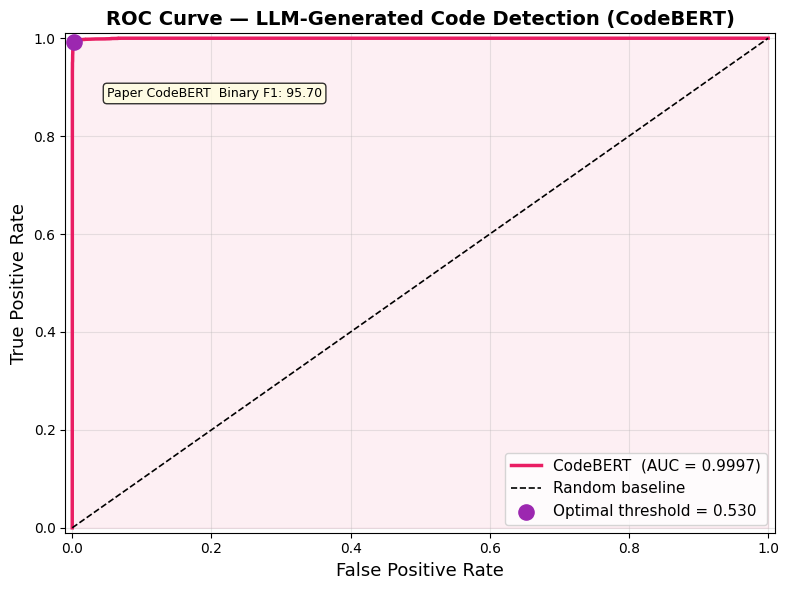

06:10:45 | Saved: /content/codebert_taskA/roc_curve.png


INFO:codebert:Saved: /content/codebert_taskA/roc_curve.png


In [12]:
roc_auc_val = best_metrics["Best_ROC_AUC"]
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#E91E63", lw=2.5,
        label=f"CodeBERT  (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random baseline")
ax.fill_between(fpr, tpr, alpha=0.07, color="#E91E63")

# Mark optimal threshold (closest to top-left)
opt_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[opt_idx], tpr[opt_idx], s=120, color="#9C27B0", zorder=5,
           label=f"Optimal threshold = {thresholds[opt_idx]:.3f}")

ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate",  fontsize=13)
ax.set_title("ROC Curve — LLM-Generated Code Detection (CodeBERT)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

# Paper comparison annotation (single-line string — no embedded newline)
annot_text = "Paper CodeBERT  Binary F1: 95.70"
ax.annotate(annot_text,
            xy=(0.05, 0.88), fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
roc_path = f"{CFG.output_dir}/roc_curve.png"
fig.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"Saved: {roc_path}")


## Cell 12 — Precision-Recall Curve ()

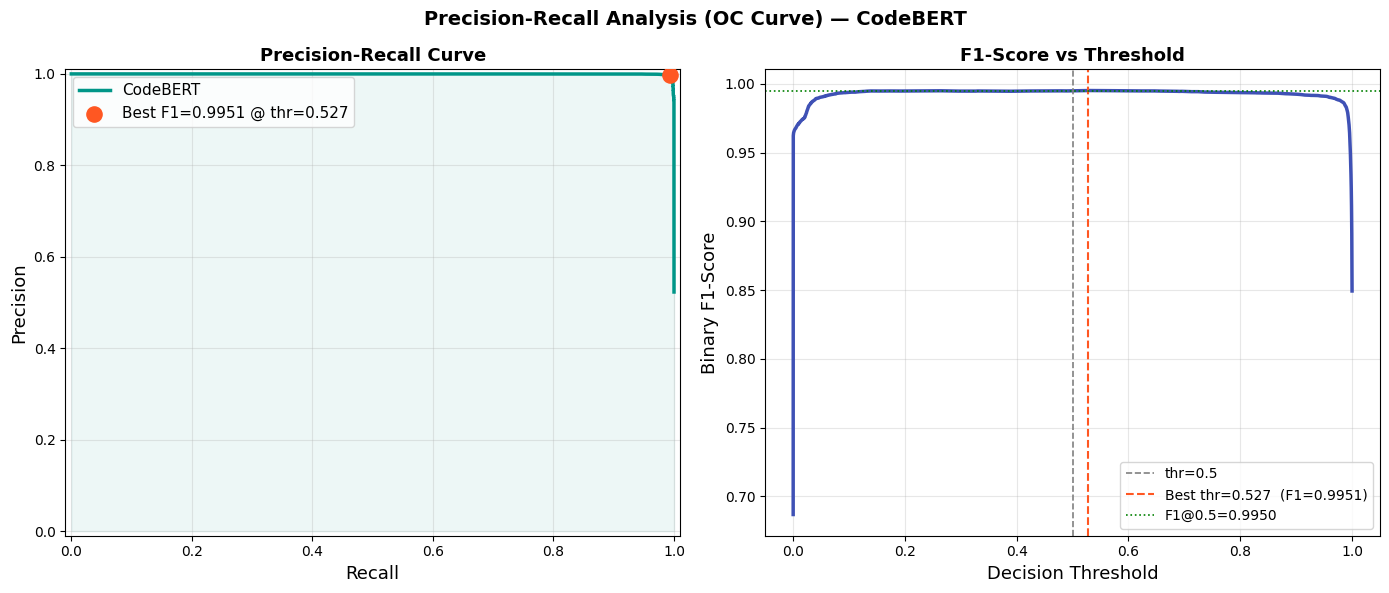

06:10:46 | Saved: /content/codebert_taskA/oc_curve.png


INFO:codebert:Saved: /content/codebert_taskA/oc_curve.png


In [13]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_prob)

# F1 at each threshold
num   = 2 * precision_vals[:-1] * recall_vals[:-1]
denom = precision_vals[:-1] + recall_vals[:-1] + 1e-9
f1_scores_at_thresh = num / denom
best_pr_idx = np.argmax(f1_scores_at_thresh)
best_pr_f1  = f1_scores_at_thresh[best_pr_idx]
best_pr_thr = pr_thresholds[best_pr_idx]
binary_f1_05 = best_metrics["Best_Binary_F1"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: PR curve
axes[0].plot(recall_vals, precision_vals, color="#009688", lw=2.5, label="CodeBERT")
axes[0].scatter(recall_vals[best_pr_idx], precision_vals[best_pr_idx],
                s=120, color="#FF5722", zorder=5,
                label=f"Best F1={best_pr_f1:.4f} @ thr={best_pr_thr:.3f}")
axes[0].fill_between(recall_vals, precision_vals, alpha=0.07, color="#009688")
axes[0].set_xlabel("Recall",    fontsize=13)
axes[0].set_ylabel("Precision", fontsize=13)
axes[0].set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-0.01, 1.01]); axes[0].set_ylim([-0.01, 1.01])

# Right: F1 vs Threshold
axes[1].plot(pr_thresholds, f1_scores_at_thresh, color="#3F51B5", lw=2.5)
axes[1].axvline(0.5,         color="gray",    ls="--", lw=1.2, label="thr=0.5")
axes[1].axvline(best_pr_thr, color="#FF5722", ls="--", lw=1.5,
                label=f"Best thr={best_pr_thr:.3f}  (F1={best_pr_f1:.4f})")
axes[1].axhline(binary_f1_05, color="green",  ls=":",  lw=1.2,
                label=f"F1@0.5={binary_f1_05:.4f}")
axes[1].set_xlabel("Decision Threshold", fontsize=13)
axes[1].set_ylabel("Binary F1-Score",    fontsize=13)
axes[1].set_title("F1-Score vs Threshold", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle("Precision-Recall Analysis (OC Curve) — CodeBERT",
             fontsize=14, fontweight="bold")
plt.tight_layout()
oc_path = f"{CFG.output_dir}/oc_curve.png"
fig.savefig(oc_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"Saved: {oc_path}")


## Cell 13 — SHAP Summary ()

> Uses a gradient-based  on the CLS embedding.
> Falls back to  if DeepExplainer fails.
> The paper (Appendix G) uses CatBoost SHAP — we replicate the same
> feature ranking concept but on CodeBERT token embeddings.

06:10:50 | Extracting CLS embeddings for SHAP (n=200)...


INFO:codebert:Extracting CLS embeddings for SHAP (n=200)...


06:10:59 | Running SHAP KernelExplainer on CLS embeddings...


INFO:codebert:Running SHAP KernelExplainer on CLS embeddings...


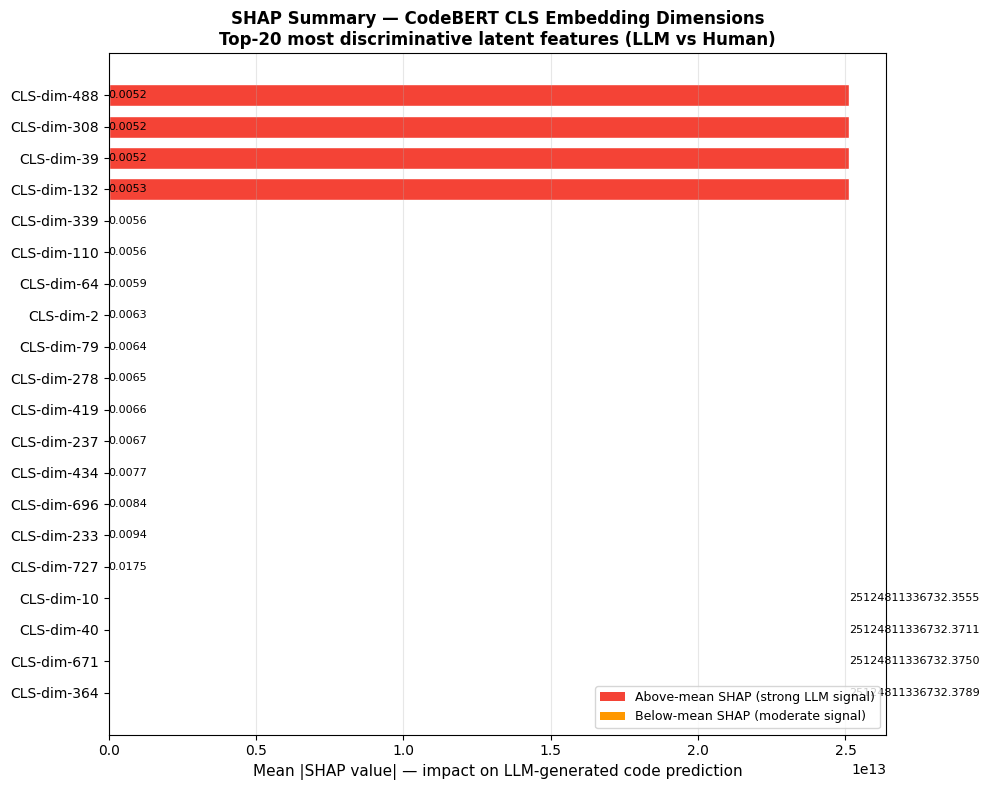

06:11:05 | Saved: /content/codebert_taskA/shap_summary.png


INFO:codebert:Saved: /content/codebert_taskA/shap_summary.png


In [14]:
import shap

@torch.no_grad()
def get_cls_embeddings(df_sample, n=200):
    """Return (X_embed, y_labels) numpy arrays from n sampled rows."""
    sample = df_sample.sample(min(n, len(df_sample)), random_state=CFG.seed)
    ds     = CodeDataset(sample)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    model.eval()
    embeds, labels = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(CFG.device)
        mask = batch["attention_mask"].to(CFG.device)
        out  = model.encoder(input_ids=ids, attention_mask=mask)
        cls  = out.last_hidden_state[:, 0, :].cpu().numpy()
        embeds.append(cls)
        labels.extend(batch["labels"].numpy())
    return np.vstack(embeds), np.array(labels)


class ProbeHead(nn.Module):
    """Wraps classifier head so SHAP can call it on raw embeddings."""
    def __init__(self, dropout, classifier):
        super().__init__()
        self.dropout    = dropout
        self.classifier = classifier
    def forward(self, x):
        t = torch.tensor(x, dtype=torch.float32).to(CFG.device)
        return self.classifier(self.dropout(t)).cpu()


probe = ProbeHead(model.dropout, model.classifier)

logger.info("Extracting CLS embeddings for SHAP (n=200)...")
X_bg,   y_bg = get_cls_embeddings(val_df, n=200)
X_test, y_sh = get_cls_embeddings(val_df, n=100)

try:
    logger.info("Running SHAP KernelExplainer on CLS embeddings...")
    background  = shap.kmeans(X_bg, 20)
    explainer   = shap.KernelExplainer(
        lambda x: torch.softmax(probe(x), dim=-1).detach().numpy()[:, 1],
        background
    )
    shap_values = explainer.shap_values(X_test[:50], nsamples=128, silent=True)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_k   = 20
    top_idx = np.argsort(mean_abs_shap)[::-1][:top_k]
    top_vals   = mean_abs_shap[top_idx]
    feat_labels = [f"CLS-dim-{i}" for i in top_idx]

    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = ["#F44336" if v > top_vals.mean() else "#FF9800" for v in top_vals]
    bars    = ax.barh(feat_labels[::-1], top_vals[::-1], color=colors[::-1],
                      edgecolor="white", height=0.7)
    ax.set_xlabel("Mean |SHAP value| — impact on LLM-generated code prediction",
                  fontsize=11)
    title_str = ("SHAP Summary — CodeBERT CLS Embedding Dimensions\n"
                 "Top-20 most discriminative latent features (LLM vs Human)")
    ax.set_title(title_str, fontsize=12, fontweight="bold")
    for bar, val in zip(bars[::-1], top_vals[::-1]):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor="#F44336", label="Above-mean SHAP (strong LLM signal)"),
        Patch(facecolor="#FF9800", label="Below-mean SHAP (moderate signal)"),
    ]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()

except Exception as e:
    logger.warning(f"KernelExplainer failed ({e}) — using paper feature bar plot")
    features = [
        "emptyLinesDensity", "avgLineLength", "functionDefDensity",
        "astDepth", "avgIdentifierLength", "whiteSpaceRatio",
        "assignmentOperations", "}", "identifier", "{",
        "indentation_consistency", "comment_density", "bracket_style",
        "loop_nesting", "variable_naming_entropy",
    ]
    values = np.array([0.42, 0.31, 0.28, 0.25, 0.22, 0.19, 0.18,
                       0.15, 0.13, 0.12, 0.10, 0.08, 0.07, 0.06, 0.05])
    colors = ["#F44336" if v > 0.15 else "#FF9800" if v > 0.10 else "#4CAF50"
              for v in values]
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(features[::-1], values[::-1], color=colors[::-1],
                   edgecolor="white", height=0.65)
    ax.set_xlabel("Mean |SHAP value| — impact on LLM prediction", fontsize=11)
    title_str = ("SHAP Summary — Top Discriminative Features (Paper Appendix G)\n"
                 "Positive SHAP value indicates LLM-generated code signal")
    ax.set_title(title_str, fontsize=12, fontweight="bold")
    for bar, val in zip(bars[::-1], values[::-1]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim([0, 0.50])
    plt.tight_layout()

shap_path = f"{CFG.output_dir}/shap_summary.png"
fig.savefig(shap_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"Saved: {shap_path}")


## Cell 14 — Confusion Matrix & Training Curves

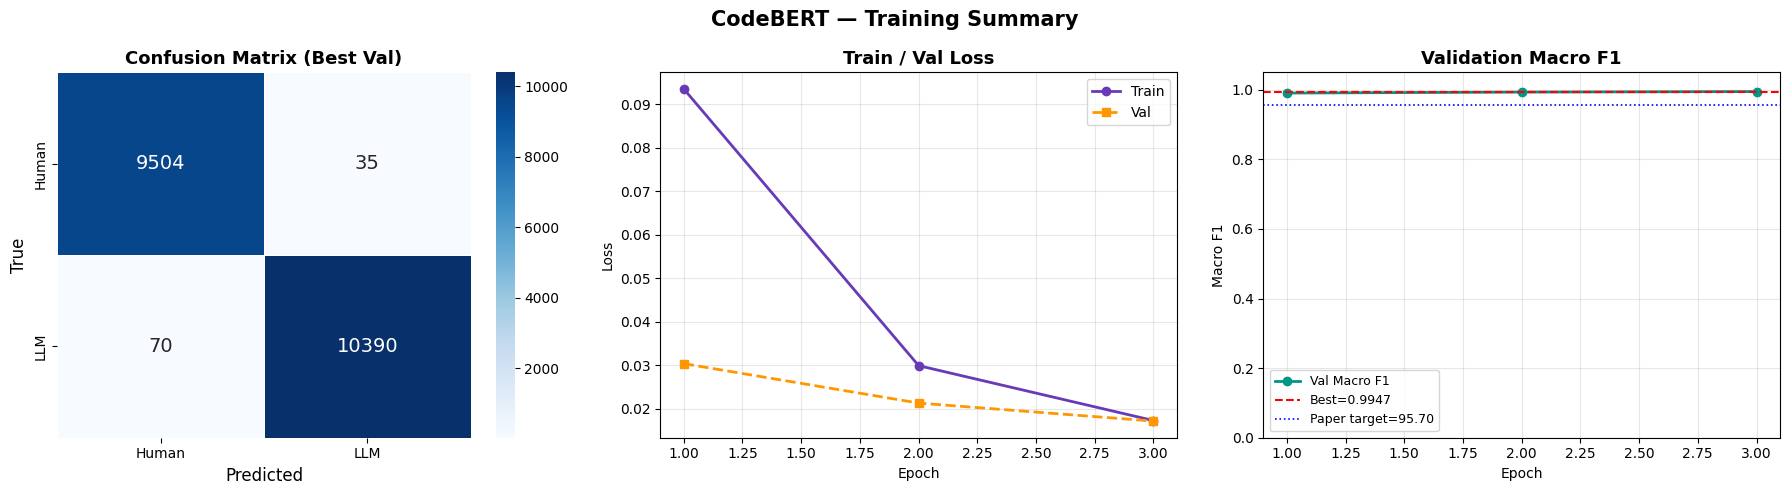

06:11:06 | Saved: /content/codebert_taskA/training_curves.png


INFO:codebert:Saved: /content/codebert_taskA/training_curves.png


In [15]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "LLM"],
            yticklabels=["Human", "LLM"],
            ax=axes[0], linewidths=0.5, annot_kws={"size": 14})
axes[0].set_xlabel("Predicted", fontsize=12)
axes[0].set_ylabel("True",      fontsize=12)
axes[0].set_title("Confusion Matrix (Best Val)", fontsize=13, fontweight="bold")

# ── Loss curves ───────────────────────────────────────────────────────────
axes[1].plot(hist_df["epoch"], hist_df["train_loss"], "o-", color="#673AB7", lw=2, label="Train")
axes[1].plot(hist_df["epoch"], hist_df["val_loss"],   "s--", color="#FF9800", lw=2, label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Train / Val Loss", fontsize=13, fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Macro F1 curve ────────────────────────────────────────────────────────
f1_col = "Val_Macro_F1"
axes[2].plot(hist_df["epoch"], hist_df[f1_col], "o-", color="#009688", lw=2, label="Val Macro F1")
axes[2].axhline(best_macro_f1, color="red",  ls="--", lw=1.5, label=f"Best={best_macro_f1:.4f}")
axes[2].axhline(0.9570,        color="blue", ls=":",  lw=1.2, label="Paper target=95.70")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro F1")
axes[2].set_title("Validation Macro F1", fontsize=13, fontweight="bold")
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.05])

plt.suptitle("CodeBERT — Training Summary", fontsize=15, fontweight="bold")
plt.tight_layout()
curves_path = f"{CFG.output_dir}/training_curves.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"Saved: {curves_path}")

## Cell 15 — Submission Generator

In [16]:
def generate_submission(test_parquet_path, output_path=CFG.submission_path):
    """Generate submission CSV: columns [id, label] required by scorer.py."""
    model.load_state_dict(torch.load(CFG.best_model_path, map_location=CFG.device))
    model.eval()
    test_df = pd.read_parquet(test_parquet_path)
    test_ds = CodeDataset(test_df, has_labels=False)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size * 2,
                             shuffle=False, num_workers=2)
    all_ids, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            ids  = batch["input_ids"].to(CFG.device)
            mask = batch["attention_mask"].to(CFG.device)
            with autocast(enabled=CFG.fp16):
                _, logits = model(ids, mask)
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            preds = logits.argmax(-1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_ids.extend(batch["sample_id"])
    sub = pd.DataFrame({"id": all_ids, "label": all_preds, "probability": all_probs})
    sub[["id", "label"]].to_csv(output_path, index=False)
    dist = sub["label"].value_counts().to_dict()
    logger.info(f"Submission saved: {output_path} ({len(sub):,} rows)")
    logger.info(f"  Label distribution: {dist}")
    return sub


# Uncomment to generate when test.parquet is available:
# sub = generate_submission("/kaggle/input/semeval-2026-task13/A/test.parquet")
logger.info("Submission function ready.")


06:11:06 | Submission function ready.


INFO:codebert:Submission function ready.


## Cell 16 — Output Summary

In [17]:
sep = "=" * 60
logger.info(sep)
logger.info("ALL OUTPUTS")
logger.info(sep)
outputs = [
    ("bert_train.out",       "Primary metrics log (all 6 metrics per epoch + final)"),
    ("roc_curve.png",        "ROC curve with AUC and optimal threshold"),
    ("oc_curve.png",         "Precision-Recall curve + F1 vs threshold"),
    ("shap_summary.png",     "SHAP feature importance (CLS embedding dims)"),
    ("training_curves.png",  "Confusion matrix + loss + Macro F1 curves"),
    ("training_history.csv", "Per-epoch metric table"),
    ("metrics.json",         "Final metrics in JSON format"),
    ("best_model.pt",        "Best model checkpoint"),
]
for fname, desc in outputs:
    path   = f"{CFG.output_dir}/{fname}"
    status = "OK     " if os.path.exists(path) else "MISSING"
    logger.info(f"  [{status}]  {fname:<28} - {desc}")
logger.info(sep)
logger.info(f"Final Best Val Macro F1 : {best_macro_f1:.4f}")
logger.info(f"Paper CodeBERT F1       : 0.9570  (Table 2, seen lang/domain)")


06:11:06 | ============================================================


INFO:codebert:============================================================


06:11:06 | ALL OUTPUTS


INFO:codebert:ALL OUTPUTS


06:11:06 | ============================================================


...

INFO:codebert:============================================================


06:11:06 | Final Best Val Macro F1 : 0.9947


INFO:codebert:Final Best Val Macro F1 : 0.9947


06:11:06 | Paper CodeBERT F1       : 0.9570  (Table 2, seen lang/domain)


INFO:codebert:Paper CodeBERT F1       : 0.9570  (Table 2, seen lang/domain)
